# 00 — Sanity & Quality

Этот ноутбук проверяет качество итогового результата **после пайплайна v2** на уже собранном UI bundle:

- `artifacts/ui/topics.parquet`
- `artifacts/ui/topics_info.parquet`
- `artifacts/ui/trends.parquet`
- `artifacts/ui/topic_examples.parquet`
- `artifacts/ui/meta.json`

Цели:
- подтвердить размер датасета, число тем, долю noise
- посмотреть распределение `topic_prob`
- посмотреть размеры тем
- быстро проверить интерпретируемость по пимерам постов


In [1]:
# imports + paths

from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

UI_DIR = Path("..") / "artifacts" / "ui"
assert UI_DIR.exists(), f"UI bundle not found: {UI_DIR.resolve()}\nRun export_ui_bundle.py first."

TOPICS_PATH = UI_DIR / "topics.parquet"
INFO_PATH = UI_DIR / "topics_info.parquet"
TRENDS_PATH = UI_DIR / "trends.parquet"
EXAMPLES_PATH = UI_DIR / "topic_examples.parquet"
META_PATH = UI_DIR / "meta.json"

for p in [TOPICS_PATH, INFO_PATH, TRENDS_PATH, EXAMPLES_PATH]:
    assert p.exists(), f"Missing file: {p.resolve()}"

print("UI_DIR:", UI_DIR.resolve())

UI_DIR: D:\ML\SocialMediaNN\artifacts\ui


In [2]:
# load

topics = pd.read_parquet(TOPICS_PATH)
topics_info = pd.read_parquet(INFO_PATH)
trends = pd.read_parquet(TRENDS_PATH)
examples = pd.read_parquet(EXAMPLES_PATH)

meta = {}
if META_PATH.exists():
    meta = json.loads(META_PATH.read_text(encoding="utf-8"))

topics["created_at"] = pd.to_datetime(topics["created_at"], utc=True, errors="coerce")
trends["time_bin"] = pd.to_datetime(trends["time_bin"], utc=True, errors="coerce")
examples["created_at"] = pd.to_datetime(examples["created_at"], utc=True, errors="coerce")

topics["topic_id"] = pd.to_numeric(topics["topic_id"], errors="coerce").fillna(-1).astype(int)
topics["topic_prob"] = pd.to_numeric(topics["topic_prob"], errors="coerce")

topics_info = topics_info.copy()
if "Topic" in topics_info.columns and "topic_id" not in topics_info.columns:
    topics_info = topics_info.rename(columns={"Topic": "topic_id"})
topics_info["topic_id"] = pd.to_numeric(topics_info["topic_id"], errors="coerce").fillna(-1).astype(int)

if "Count" in topics_info.columns:
    topics_info["Count"] = pd.to_numeric(topics_info["Count"], errors="coerce")

examples["topic_id"] = pd.to_numeric(examples["topic_id"], errors="coerce").fillna(-1).astype(int)
if "topic_prob" in examples.columns:
    examples["topic_prob"] = pd.to_numeric(examples["topic_prob"], errors="coerce")

print("topics:", topics.shape, list(topics.columns))
print("topics_info:", topics_info.shape, list(topics_info.columns))
print("trends:", trends.shape, list(trends.columns))
print("examples:", examples.shape, list(examples.columns))
print("meta keys:", list(meta.keys()))

topics: (723039, 6) ['post_id', 'topic_id', 'topic_prob', 'created_at', 'url', 'text']
topics_info: (100, 8) ['topic_id', 'Count', 'Name', 'Representation', 'KeyBERT', 'MMR', 'Representative_Docs', 'keywords']
trends: (34222, 7) ['time_bin', 'topic_id', 'n_posts', 'avg_prob', 'share', 'n_posts_prev', 'growth']
examples: (1200, 5) ['topic_id', 'topic_prob', 'created_at', 'url', 'text']
meta keys: ['profile_name', 'sources', 'bundle', 'stats', 'examples_cfg', 'columns']


In [3]:
# KPI

n_docs = len(topics)
n_unique_topics = topics["topic_id"].nunique(dropna=False)
noise_share = (topics["topic_id"] == -1).mean()

p = topics["topic_prob"].dropna()
kpi = {
    "n_docs": n_docs,
    "n_unique_topics_including_noise": int(n_unique_topics),
    "noise_share": float(noise_share),
    "median_topic_prob": float(p.median()) if len(p) else None,
    "share_prob_ge_0_2": float((topics["topic_prob"] >= 0.2).mean()),
    "share_prob_ge_0_3": float((topics["topic_prob"] >= 0.3).mean()),
    "share_prob_ge_0_4": float((topics["topic_prob"] >= 0.4).mean()),
}
kpi

{'n_docs': 723039,
 'n_unique_topics_including_noise': 100,
 'noise_share': 0.45217477895383235,
 'median_topic_prob': 0.5838655107394239,
 'share_prob_ge_0_2': 0.7048292000846428,
 'share_prob_ge_0_3': 0.6441934667424579,
 'share_prob_ge_0_4': 0.58676917842606}

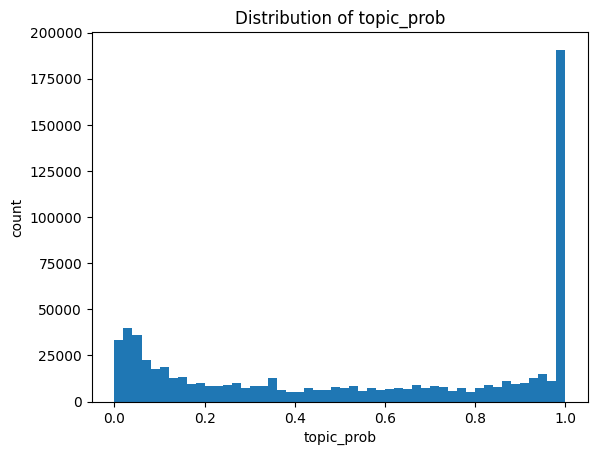

In [4]:
# topic_prob histogram

plt.figure()
vals = topics["topic_prob"].dropna().values
plt.hist(vals, bins=50)
plt.title("Distribution of topic_prob")
plt.xlabel("topic_prob")
plt.ylabel("count")
plt.show()

In [5]:
# top topic sizes)

vc = topics["topic_id"].value_counts()
top20 = vc.head(20).to_frame("count")
top20

,count
topic_id,
-1,326940
0,74356
1,36802
2,17057
3,15570
4,14833
6,12414
5,12191
7,9385


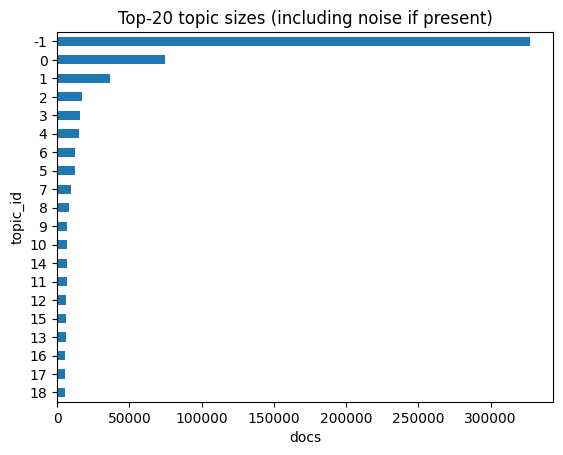

In [6]:
# bar chart top-20 sizes

plt.figure()
top20["count"].iloc[::-1].plot(kind="barh")
plt.title("Top-20 topic sizes (including noise if present)")
plt.xlabel("docs")
plt.ylabel("topic_id")
plt.show()

In [7]:
# coherence of “coverage”

coverage_non_noise = 1.0 - noise_share
coverage_prob_ge_04 = (topics["topic_id"].ne(-1) & (topics["topic_prob"] >= 0.4)).mean()

coverage = {
    "coverage_non_noise": float(coverage_non_noise),
    "coverage_non_noise_prob_ge_0_4": float(coverage_prob_ge_04),
}
coverage

{'coverage_non_noise': 0.5478252210461676,
 'coverage_non_noise_prob_ge_0_4': 0.41698580574491834}

In [8]:
# sample interpretability: show topics + examples

# pick topics by size excluding noise
top_topic_ids = [tid for tid in vc.index.tolist() if tid != -1][:8]

# try to get readable keywords
if "keywords" not in topics_info.columns:
    topics_info["keywords"] = topics_info.get("Representation", "")

display = topics_info[topics_info["topic_id"].isin(top_topic_ids)][["topic_id"] + [c for c in ["Name", "keywords", "Count"] if c in topics_info.columns]]
display = display.sort_values("topic_id")
display

,topic_id,Name,keywords,Count
1,0,0_my_credit_to_have,"[my, credit, to, have, and, for, money, pay, i...",20402
2,1,1_book_books_read_reading,"[book, books, read, reading, of, you, the, by,...",11275
3,2,2_game_games_wii_xbox,"[game, games, wii, xbox, deleted, nintendo, vi...",5217
4,3,3_trip_travel_we_to,"[trip, travel, we, to, in, days, day, stay, an...",4740
5,4,4_moon_earth_eclipse_solar,"[moon, earth, eclipse, solar, asteroid, lunar,...",4359
6,5,5_mars_space_nasa_launch,"[mars, space, nasa, launch, rover, spacex, cur...",3914
7,6,6_iphone_apple_samsung_galaxy,"[iphone, apple, samsung, galaxy, smartphone, a...",3733
8,7,7_tablet_gadgets_watch_laptop,"[tablet, gadgets, watch, laptop, smartwatch, a...",2626


In [9]:
# print examples for each topic

for tid in top_topic_ids:
    print("=" * 80)
    print(f"Topic {tid}")
    kw = topics_info.loc[topics_info["topic_id"] == tid, "keywords"]
    if len(kw):
        print("keywords:", str(kw.iloc[0])[:200])

    ex = examples[examples["topic_id"] == tid].sort_values("topic_prob", ascending=False).head(5)
    if ex.empty:
        print("No examples in bundle for this topic.")
        continue

    for i, r in enumerate(ex.itertuples(index=False), start=1):
        txt = str(r.text)
        txt = (txt[:400] + " ...") if len(txt) > 400 else txt
        print(f"\n[{i}] p={getattr(r, 'topic_prob', np.nan):.3f}")
        print(txt)
        if getattr(r, "url", None):
            print("url:", r.url)

Topic 0
keywords: ['my' 'credit' 'to' 'have' 'and' 'for' 'money' 'pay' 'is' 'it']

[1] p=1.000
Expense ratios and fees in my 401(k) I've been reading through threads on /r/personalfinance and /r/portfolios for the last few months since PF became a default. I've learned a lot and have already made significant changes to my portfolio for the better. Now on to my question. I was just reading through the latest documentation from my 401(k) that I got around the recent quarter end about availabl ...
url: https://www.reddit.com/r/personalfinance/comments/2avp64/expense_ratios_and_fees_in_my_401k/

[2] p=1.000
Feel like my 401k is getting eaten up by expense ratios-Advice Appreciated I'm a teacher in NC and I'm invested in the NC401k program. I do not get a company match and invest 10% of my salary into it. I set my portfolio to Aggressive via the Goalmaker program Prudential offers, but I am thinking of turning Goalmaker off and allocating the money myself. However, I could use some advice a

# Conclusions — Sanity & Quality Check

## Dataset & coverage

- После preprocess v2 в корпусе осталось 723 039 документов.

- Итоговое число тем: 100 (включая noise-тему -1).

- Доля noise: ≈ 45.2% — ожидаемо высокая для реального, многодоменного и шумного социального текста.

- Topic assignment quality

- Медианная вероятность темы (topic_prob) составляет ≈ 0.584, что говорит о достаточно уверенном присвоении тем для значительной части документов.

## Доли документов по порогам вероятности:

- topic_prob ≥ 0.2: ≈ 70.5%

- topic_prob ≥ 0.3: ≈ 64.4%

- topic_prob ≥ 0.4: ≈ 58.7%

Это означает, что более половины всего корпуса имеет достаточно “чёткую” тематическую принадлежность даже при строгом пороге 0.4.

## Coverage vs. confidence

- Покрытие non-noise темами: ≈ 54.8% документов.

- Покрытие non-noise темами с topic_prob ≥ 0.4: ≈ 41.7% документов.

- Для BERTopic на шумном социальном корпусе такие значения являются хорошим компромиссом между интерпретируемостью и честностью модели: мы не “насильно” загоняем документы в темы.

## Topic size distribution

- Noise-тема (-1) — крупнейшая: ≈ 327k документов.

- Крупнейшие осмысленные темы имеют размеры от ~70k до ~5k документов, что указывает на:

    - отсутствие доминирования одной-двух тем,

    - хорошую тематическую диверсификацию корпуса,

    - адекватную работу topic reduction до 100 тем.

## Interpretability

### Топ-темы (например, credit, books/reading, games, travel, space, smartphones) демонстрируют:

- понятные, семантически связные keywords,

- высокие topic_prob у representative examples,

- согласованность между keywords и реальными текстами постов.

Это подтверждает, что связка

**SBERT (MiniLM) → UMAP → HDBSCAN → BERTopic + KeyBERT/MMR**

даёт интерпретируемые и устойчивые темы даже на масштабном и шумном корпусе.

## Overall assessment

- Результат нельзя назвать “идеально чистым” — и это осознанное дизайнерское решение проекта.

- Модель честно отражает структуру реального социального потока:

    - показывает noise,

    - даёт вероятности,

    - позволяет пользователю выбирать пороги уверенности.

Такой подход делает систему пригодной для исследовательского анализа трендов, а не только для демонстрационных датасетов.

## Next steps

- Использовать topic_prob и noise-фильтры как ключевые элементы UI.

- Анализировать тренды как:

- абсолютные (share),

- относительные (z-score),

- динамические (Δshare).

- При необходимости — сравнивать стабильность тем между запусками или периодами....
